In [1]:
import numpy as np
import os
from scipy.optimize import curve_fit
import saphires as saph
import pickle as pkl
from scipy.ndimage import gaussian_filter
import scipy

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline 

In [3]:
star = 'HUVir'#"29Dra"
path = r'C:\Users\astro\SSGs\stars\\' + star + '\\' #from jonah's RV txt
spec_path = r'C:\Users\astro\SSG_Spectra\H-alpha_Analysis'
datfile = path + star + "_coude_head.dat"
image_path = spec_path + '\General_Spectral_Analysis\Spectral_Images\\'
RV_file =  r'C:\Users\astro\SSGs\starstxt4' + '\\' + star + '\\' + star + '_asymmetric_fits\\'

Ha_file = spec_path + "\Analyze_Spectra\Analyze_" + star + ".txt"
CaH_file = spec_path + '\Analyze_CaH\CaH_Analyze_' + star + '.txt'
CaK_file = spec_path + '\Analyze_CaH\CaK_Analyze_' + star + '.txt'

#Constants
R_coude = 60000.0 #spectral resolution of the Coude. 
c = (2.9979245*10**5) #speed of light

#Constants
R_coude = 60000.0 #spectral resolution of the Coude. 
c = 2.9979245e5 #speed of light in km/s
M_sun = 1.988416E30 #kg
R_sun = 6.95700E5 #km
AU = 1.49597870700E8 #km
G = 6.674E-11 #N*m/kg

# Functions

In [4]:
#Functions 

#File Finder
def fitfile_open(file_name):
    with open(file_name, 'r') as file:
        fit_data = [line.strip().split("/") for line in file]
    
    dat_type = fit_data[0]
    del fit_data[0]
    return fit_data, dat_type

#Returns Guesses, parameters 
def guess_find(fit_dat, print_dates = False):
    guess = [np.array(temp[7].strip('[]').split(","), dtype = float) for temp in fit_dat]
    lims = [np.array(res[6].strip('[]').split(","), dtype = float) for res in fit_dat]
    date_line = [day[1] for day in fit_dat]

    if print_dates == True:
        return lims, guess, date_line
    else:
        return lims, guess

#Wavelength to velocity conversion
def velocity_spec(wav, bvcorr, lam, rv=0):
    v_spec = ((wav-lam)/lam)*c + bvcorr + (bvcorr/c) - rv
    return v_spec

def vel_to_wav(vel, bvcorr, lam):
    l_vel = lam * ((vel - bvcorr)/c + 1)
    return l_vel


#Filters wavelengths to certain points
def filterer(region, bounds, spect):  
    spec_where = np.where((spect['wav'][region]>bounds[0]) & (spect['wav'][region]<bounds[1]))
    tempList_wavelength = spect['wav'][region][spec_where]
    tempList_flux = spect['flux'][region][spec_where]
    
    return  tempList_flux,  tempList_wavelength

#Adjust boundaries of spectrum
def adjust_bounds(arr, arr2, bounds):
    filt_where = np.where((arr > bounds[0]) & (arr < bounds[1]))
    tempList_wav = arr[filt_where]
    tempList_flux2 = arr2[filt_where]
    return tempList_flux2, tempList_wav

def gauss(x, *p): 
    A, mu, sigma, B = p
    y = A * np.exp(-((x - mu)**2)/(2 * sigma ** 2 )) + B
    return y

def gauss_fit(region, spect, bounds, guesses):
    '''
    
    '''
    #filter
    spec_where = np.where((spect['wav'][region]>bounds[0]) & (spect['wav'][region]<bounds[1]))
    wav = spect['wav'][region][spec_where]
    flux = spect['flux'][region][spec_where]
    
    popt, pcov = scipy.optimize.curve_fit(gauss, wav, flux, guesses)
    fit_flux = gauss(wav, popt[0], popt[1], popt[2], popt[3])
    return wav, flux, popt

def integrate(popt):
    upperlam = popt[1]+2
    lowerlam = popt[1]-2
    IntHa = scipy.integrate.quad(gauss, lowerlam, upperlam, args = (popt[0], popt[1], popt[2],popt[3]))
    Int1 = (upperlam - lowerlam)
    B = popt[3]
    Int2 = IntHa[0]/B
    IntHA = Int1-Int2
    return IntHA


# Load Files Here

In [5]:
with open(RV_file + star + '.txt', 'r') as file:
    rv_overview_data = file.readlines()
rv_overview_data
#rv data
with open(RV_file + star + '_RVs.txt', 'r') as file:
    dat_RV = file.readlines()
    
with open(RV_file + star + '_vsini.txt', 'r') as file:
    dat_vsini = file.readlines()   

rv_data = [k.strip(',\n').strip('[]').strip("\"\"").strip(']').split(',') for k in dat_RV]
vsini_data = [k.strip(',\n').strip('[]').strip("\"\"").strip(']').split(',') for k in dat_vsini]

#Coude Data
with open(datfile, 'r') as file:
    datfile_data = [line.strip().split(",") for line in file]
del datfile_data[0]   

#Opens ha fit parameters
ha_data, ha_datTypes = fitfile_open(Ha_file)
CaH_data, CaH_datTypes = fitfile_open(CaH_file)
CaK_data, CaK_datTypes = fitfile_open(CaK_file)


In [6]:
print('Is there bad/Missing data: ', len(rv_data) != len(datfile_data))
for i in range(len(rv_data)):
    print(datfile_data[i][0], rv_data[i][0])

Is there bad/Missing data:  False
HUVir_2020-05-10_0.pkl 2458979.70042
HUVir_2021-01-31_0.pkl 2459245.95337
HUVir_2021-03-30_0.pkl 2459303.79537
HUVir_2021-04-01_0.pkl 2459305.75226
HUVir_2021-04-23_0.pkl 2459327.68030
HUVir_2021-04-24_0.pkl 2459328.73100
HUVir_2021-04-25_0.pkl 2459329.73732
HUVir_2021-05-04_0.pkl 2459338.76756
HUVir_2021-05-29_0.pkl 2459363.63199
HUVir_2021-05-29_1.pkl 2459363.66814
HUVir_2021-05-30_0.pkl 2459364.65690
HUVir_2021-12-14_0.pkl 2459563.01470


In [7]:
data = np.array(datfile_data)
numFiles = len(data)
files = data[:,0]

In [8]:
#Loading Files
specs=[]
for file in files:
    spec = pkl.load(open(path + file, 'rb'))
    specs.append(spec)


# Gather Data Here

In [9]:
specs[0].keys()

print(specs[0].keys())

dict_keys(['wav', 'flux', 'object'])


In [10]:
#for i in range(spec['wav'].shape[0]):
    #print(i,spec['wav'][i,0],spec['wav'][i,-1])#

In [11]:
#-----------------------------------------------------Spectral Lines
#H-alpha
o_ha = 39
l_ha= 6562.8

l_CaH = 3968.47
o_CaH = 5

l_CaK = 3933.66
o_CaK = 4

o_hb = 20
l_hb = 4861.35

o_hy = 12
l_hy = 4340.472

o_Hd = 7
l_Hd = 4101.75

o_Li = 40
l_Li = 6707.8

#------------------------------------------BVCORRs, BJDs, dates from coude header data
BVCORRs = np.array(data[:,6], float)
BJDs = np.array(data[:,5], float)
date = [s.split('_')[1] for s in files]

#AV_RV and RV_STD
av_RV = float(rv_overview_data[5].split(' ')[-2])
av_RV_sec = float(rv_overview_data[20].split(' ')[-2])
RV_STD = float(rv_overview_data[6].split(' ')[-2])
RV_STD_sec = float(rv_overview_data[21].split(' ')[-2])
print('Average RV: ', av_RV, '\t', 'RV STDEV:', RV_STD)
print('Average RV: ', av_RV_sec, '\t', 'RV STDEV:', RV_STD_sec)

#RVs and Vsinis

RVs = [float(rad_vel[1]) for rad_vel in rv_data]
vsinis = [float(vsini[1]) for vsini in vsini_data]
RVs_sec = [float(rad_vel[3]) for rad_vel in rv_data]
vsinis_sec = [float(vsini[3]) for vsini in vsini_data]

#Fitting Data
lims_ha, guesses_ha, ha_dates = guess_find(ha_data, True) #Needed For H-alpha Fits
lims_CaH, guesses_CaH = guess_find(CaH_data)
lims_CaK, guesses_CaK = guess_find(CaK_data)


Average RV:  -1.167 	 RV STDEV: 35.172
Average RV:  23.457 	 RV STDEV: 31.226


# Sort Index By Radial Velocity

In [ ]:
RVs_list1 = np.array(RVs)*-1

rvs_index = RVs_list1.argsort()
for item in rvs_index:
    print(item, RVs[item], date[item])

# Spectral Images

In [ ]:
#Color Coding
line_color =  '#b44586'
CoM_color = '#52730b'
wav_color = 'tab:blue'
fit_color = 'tab:orange'

peak_color = '#87255f'

In [ ]:
def plt_spectrum(spect_index,l_spec,o_spec, ax_name, xlim = [None, None], fit_lim = [None, None], 
                 sguesses=[1,1,1,1], ylim= [None,None],
             l_col = line_color, lsec_col = 'b', CoM_col = CoM_color, 
             spec_col = 'tab:blue', gauss_col = 'tab:orange', peak_col = peak_color, 
             line_class = None, RV_Mode = True, plt_gauss = False, plt_peak = False, plt_sec = False):
    
    spect = specs[spect_index]
    #set wavelength flux
    flux, wavelength = filterer(o_spec, lims, spect)
    if (plt_gauss == True) or (plt_peak == True):
        popt, pcov = scipy.optimize.curve_fit(gauss, wavelength, flux, guesses)
        fit_flux = gauss(wavelength, popt[0], popt[1], popt[2], popt[3])
        peak = popt[1]
        
        if RV_Mode == True:
            fit_vspec = velocity_spec(fit_vspec, BVCORRs[spect_index],l_spec)
            peak = velocity_spec(peak, BVCORRs[spect_index], l_spec)
    
    if RV_Mode == False:
        v_spec = wavelength
        com_rv = vel_to_wav(av_RV, BVCORRs[spect_index], l_spec)
        low_vsini = vel_to_wav(RVs[spect_index] - vsinis[spect_index], BVCORRs[spect_index], l_spec) 
        hi_vsini = vel_to_wav(RVs[spect_index] + vsinis[spect_index], BVCORRs[spect_index], l_spec)
        prim_rv  = vel_to_wav(RVs[spect_index], BVCORRs[spect_index], l_spec)
        x_label = 'Wavelength (A)'
        x_unit = 'Wavelength (A)'
    else:
        v_spec = velocity_spec(wavelength, BVCORRs[spect_index], l_spec)
        com_rv = av_RV
        low_vsini = RVs[spect_index] - vsinis[spect_index]
        hi_vsini = RVs[spect_index] + vsinis[spect_index]
        prim_rv  =  RVs[spect_index]
        sec_rv = RVs_sec[spect_index]
        x_label  = 'Barycentric Radial Velocity (km/s)'
        x_unit = 'km/s'
        
    #Title
    if line_class == None:
        fig_title = date[spect_index]
    else:
        fig_title = date[spect_index] + " (" + str(line_class) + ")"
    
    
    #Plot
    ax_name.set_title(fig_title, fontsize = 24)
        #Shaded Region
    ax_name.axvline(low_vsini, color = l_col, ls = "--", alpha = 0.3)
    ax_name.axvline(hi_vsini, color = l_col, ls = "--", alpha = 0.3)
    ax_name.axvspan(low_vsini, hi_vsini, alpha=0.3, color= l_col)
 
    ax_name.plot(v_spec, flux, 'ko', ms = 9, mec = l_col)
    ax_name.plot(v_spec, flux, color = spec_col ,lw = 3)
    
    #Plot Gaussian
    if plt_gauss == True:
         ax.plot(fit_vspec, fit_flux, color = gauss_col, lw = 3)
    
    #Plot Lines
    ax_name.axvline(prim_rv, color = l_col, ls = '--', label ='Primary RV', lw = 4)
    ax_name.axvline(com_rv, color = CoM_col, ls = '-', label = 'CoM RV', lw = 4)
    ax_name.axvline(sec_rv, color = CoM_col, ls = ':', label ='Primary RV', lw = 4)
    
    
    if plt_peak == True:
            ax.axvline(peak, color = peak_col, ls = '-.',lw = 4)
            print('peak velocity at', date[spec_index],'=',peak,x_unit,
                  ';\n Vel/Wav Diff between primary and peak:', peak - prim_rv, x_unit)
            
    #Limits and Labels       
    ax_name.set_xlim(xlim)
    ax_name.set_ylim(ylim)
    ax_name.set_ylabel('Flux', fontsize = 24)
    ax_name.set_xlabel(x_label, fontsize = 24)
    ax_name.legend(fontsize= 24)
    ax_name.tick_params(axis='both', labelsize = 24)
    

In [ ]:

def plt_spec(spect, index, l_spec, o_spec, lims, guesses, ax_name, plt_place = [0,0], 
              l_col = 'r', lsec_col = 'b', CoM_col = 'm', spec_col = 'tab:blue', gauss_col = 'tab:orange', peak_col = 'g',
              xlims = ['none', 'none'], ylims = ['none', 'none'], 
             line_class = None, RV_Mode = True, plt_gauss = False, plt_peak = False, plt_sec = False):
    
    #Fits Gaussian
    flux, wavelength = filterer(o_spec, lims, spect)
    if (plt_gauss == True) or (plt_peak == True):
        popt, pcov = scipy.optimize.curve_fit(gauss, wavelength, flux, guesses)
        fit_flux = gauss(wavelength, popt[0], popt[1], popt[2], popt[3])
        peak = popt[1]
    else:
        peak = 0
        
    if RV_Mode == False:
        v_spec = wavelength
        com_rv = vel_to_wav(av_RV, BVCORRs[index], l_spec)
        low_vsini = vel_to_wav(RVs[index] - vsinis[index], BVCORRs[index], l_spec) 
        hi_vsini = vel_to_wav(RVs[index] + vsinis[index], BVCORRs[index], l_spec)
        prim_rv  = vel_to_wav(RVs[index], BVCORRs[index], l_spec)
        x_label = 'Wavelength (A)'
        x_unit = 'Wavelength (A)'
    else:
        v_spec = velocity_spec(wavelength, BVCORRs[index], l_spec)
        com_rv = av_RV
        low_vsini = RVs[index] - vsinis[index]
        hi_vsini = RVs[index] + vsinis[index]
        prim_rv  =  RVs[index]
        peak = velocity_spec(peak, BVCORRs[index], l_spec)
        x_label  = 'Barycentric Radial Velocity (km/s)'
        x_unit = 'km/s'
    
    #Colors
    l_col = l_col
    CoM_col = CoM_col
    spec_col = spec_col
    lsec_col = lsec_col
    gauss_col = gauss_col
    
    #plt placements
    row, col = plt_place
    
    #xlim and ylims
    xlim1, xlim2 = xlims
    ylim1, ylim2  = ylims
    
    #sets Title
    if line_class == None:
        fig_title = date[index]
    else:
        fig_title = date[index] + " (" + str(line_class) + ")"

    #Axis type
    if (row == None ) and (col == None):
        #Plot
        fig, ax = plt.subplots(figsize=(10,7))
        ax.set_title(fig_title, fontsize = 24)
        #Shaded Region
        ax.axvline(low_vsini, color = l_col, ls = "--", alpha = 0.3)
        ax.axvline(hi_vsini, color = l_col, ls = "--", alpha = 0.3)
        ax.axvspan(low_vsini, hi_vsini, alpha=0.3, color= l_col)
        #Fits
        ax.plot(v_spec, flux, 'ko', ms = 9, mec = l_col)
        ax.plot(v_spec, flux, color = spec_col ,lw = 3)

        if plt_gauss == True:
            ax.plot(v_spec, fit_flux, color = gauss_col, lw = 3)
            
            #Set X and y lims
        if (xlim1 != 'none') and (xlim2 != 'none'):
            ax.set_xlim(xlim1, xlim2)
        elif(xlim1 == 'none') and (xlim2 != 'none'):
            ax.set_xlim(right=xlim2)
        elif(xlim1 != 'none') and (xlim2 == 'none'):
            ax.set_xlim(left=xlim1)

        if (ylim1 != 'none') and (ylim2 != 'none'):
            ax.set_ylim(ylim1, ylim2)
        elif(ylim1 == 'none') and (ylim2 != 'none'):
            ax.set_ylim(top = ylim2)
        elif(ylim1 != 'none') and (ylim2 == 'none'):
            ax.set_ylim(bottom=ylim1)
        #Spec Lines
        ax.axvline(prim_rv, color = l_col, ls = '--', label ='Primary RV', lw = 4)
        ax.axvline(com_rv, color = CoM_col, ls = '-', label = 'CoM RV', lw = 4)
        
        if plt_peak == True:
            ax.axvline(peak, color = peak_col, ls = '-.',lw = 4)
            print('peak velocity at', date[index],'=',peak,x_unit,
                  ';\n Vel/Wav Diff between primary and peak:', peak - prim_rv, x_unit)

        #Set Labels
        ax.set_ylabel('Flux', fontsize = 24)
        ax.set_xlabel(x_label, fontsize = 24)
        ax.legend(fontsize= 24)
        ax.tick_params(axis='both', labelsize = 24)
        
        
        return fig

    elif ((row == None) or (col == None)):
        if (row == None):
            row = col
        #Plot
        ax_name[row].set_title(fig_title, fontsize = 24)
        #Shaded Region
        ax_name[row].axvline(low_vsini, color = l_col, ls = "--", alpha = 0.3)
        ax_name[row].axvline(hi_vsini, color = l_col, ls = "--", alpha = 0.3)
        ax_name[row].axvspan(low_vsini, hi_vsini, alpha=0.3, color= l_col)
        #Fits
        ax_name[row].plot(v_spec, flux, 'ko', ms = 9, mec = l_col)
        ax_name[row].plot(v_spec, flux, color = spec_col ,lw = 3)

        if plt_gauss == True:
            ax_name[row].plot(v_spec, fit_flux, color = gauss_col, lw = 3)

        #Spec Lines
        ax_name[row].axvline(prim_rv, color = l_col, ls = '--', label ='Primary RV', lw = 4)
        ax_name[row].axvline(com_rv, color = CoM_col, ls = '-', label = 'CoM RV', lw = 4)
        if plt_peak == True:
            ax_name[row].axvline(peak, color = peak_col, ls = '-.',lw = 4)
            print('peak velocity at', date[index],'=',peak,x_unit,
                  ';\n Vel/Wav Diff between primary and peak:', peak - prim_rv, x_unit)
            
        #Set X and y lims
        if (xlim1 != 'none') and (xlim2 != 'none'):
            ax_name[row].set_xlim(xlim1, xlim2)
        elif(xlim1 == 'none') and (xlim2 != 'none'):
            ax_name[row].set_xlim(right=xlim2)
        elif(xlim1 != 'none') and (xlim2 == 'none'):
            ax_name[row].set_xlim(left=xlim1)

        if (ylim1 != 'none') and (ylim2 != 'none'):
            ax_name[row].set_ylim(ylim1, ylim2)
        elif(ylim1 == 'none') and (ylim2 != 'none'):
            ax_name[row].set_ylim(top = ylim2)
        elif(ylim1 != 'none') and (ylim2 == 'none'):
            ax_name[row].set_ylim(bottom=ylim1)

        #Set Labels
        ax_name[row].set_ylabel('Flux', fontsize = 24)
        ax_name[row].set_xlabel(x_label, fontsize = 24)
        ax_name[row].legend(fontsize= 24)
        ax_name[row].tick_params(axis='both', labelsize = 24)

    else: 
        
        #Plot
        ax_name[row][col].set_title(fig_title, fontsize = 24)
        #Shaded Region
        ax_name[row][col].axvline(low_vsini, color = l_col, ls = "--", alpha = 0.3)
        ax_name[row][col].axvline(hi_vsini, color = l_col, ls = "--", alpha = 0.3)
        ax_name[row][col].axvspan(low_vsini, hi_vsini, alpha=0.3, color= l_col)
        #Fits
        ax_name[row][col].plot(v_spec, flux, 'ko', ms = 9, mec = l_col)
        ax_name[row][col].plot(v_spec, flux, color = spec_col ,lw = 3)

        if plt_gauss == True:
            ax_name[row][col].plot(v_spec, fit_flux, color = gauss_col, lw = 3)
        #Spec Lines
        ax_name[row][col].axvline(prim_rv, color = l_col, ls = '--', label ='Primary RV', lw = 4)
        ax_name[row][col].axvline(com_rv, color = CoM_col, ls = '-', label = 'CoM RV', lw = 4)
        if plt_peak == True:
            ax_name[row][col].axvline(peak, color = peak_col, ls = '-.',lw = 4)
            print('peak velocity at', date[index],'=',peak,x_unit,
                  ';\n Vel/Wav Diff between primary and peak:', peak - prim_rv, x_unit)

        #Set X and y lims
        if (xlim1 != 'none') and (xlim2 != 'none'):
            ax_name[row][col].set_xlim(xlim1, xlim2)
        elif(xlim1 == 'none') and (xlim2 != 'none'):
            ax_name[row][col].set_xlim(right=xlim2)
        elif(xlim1 != 'none') and (xlim2 == 'none'):
            ax_name[row][col].set_xlim(left=xlim1)

        if (ylim1 != 'none') and (ylim2 != 'none'):
            ax_name[row][col].set_ylim(ylim1, ylim2)
        elif(ylim1 == 'none') and (ylim2 != 'none'):
            ax_name[row][col].set_ylim(top = ylim2)
        elif(ylim1 != 'none') and (ylim2 == 'none'):
            ax_name[row][col].set_ylim(bottom=ylim1)

        #Set Labels
        ax_name[row][col].set_ylabel('Flux', fontsize = 24)
        ax_name[row][col].set_xlabel(x_label, fontsize = 24)
        ax_name[row][col].legend(fontsize= 24)
        ax_name[row][col].tick_params(axis='both', labelsize = 24)

'''
plot_spec(spect, index, l_spec, o_spec, lims, guesses, 
              ax_name, plt_place = [0,0], 
              l_col = 'r', CoM_col = 'm', spec_col = 'tab:blue', gauss_col = 'tab:orange',
              xlims = ['none', 'none'], ylims= ['none', 'none'], line_class = None,
              RV_Mode = True, plt_gauss = False, plt_sec = False);
              
plt_spec(spect = spec12, index = 11, l_spec = l_CaK, o_spec = o_CaK, 
         lims = lims_CaK[11], guesses = guesses_CaK[11], ax_name = ax, plt_place = [0,0],
         l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, gauss_col = 'tab:orange',    
         xlims = ['none', 'none'], ylims = ['none', 'none'], line_class = "Normal Ca+K", 
         RV_Mode = True, plt_gauss = False, plt_sec = False)
'''

# H-alpha Comparison

Create a figure of H-alpha Profiles like those shown in this paper https://iopscience.iop.org/article/10.1086/313242/pdf

In [ ]:
xwav_ha = [5656, 5670] 
spectra_col = 'k'
#specs = [spec, spec2, spec3, spec4, spec5, spec6, spec7, spec8, spec9, spec10, spec11, spec12]
spec_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 
               'tab:gray', 'tab:olive', 'tab:cyan', 'teal', 'gold']

In [ ]:
def phasing(period, times, t0):
    t0 = t0
    phase = (times - t0)/period %1
    return phase

In [ ]:
phase = phasing(10.387678, BJDs, t0 = BJDs[3])

#print(phase)
phase_date = np.array([phase, date])

p_index = phase_date[0].argsort()

phase2 = phasing(10.387678, BJDs, t0 = 2449993.1950)
p_index2 = phase2.argsort()

#for i in p_index2:
    #print(date[i],'\t', phase2[i])
#print(phase)

In [ ]:
for i in p_index2:
    print(i, date[i],'\t', phase2[i])


In [ ]:
def phase_plot(period, times, t0, bound = 7, o_spec = o_ha, l_line = l_ha, 
               line_name = "H-alpha", RV_Mode = False, low_lim = None, x_place = l_ha - 6.5, 
               cent_rv = False, t0_label = 'periastron'):
    x_base = 0
    spec_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 
               'tab:gray', 'tab:olive', 'tab:cyan', 'teal', 'gold']
   
    #Calculating Phases
    phases = phasing(period, times, t0)
    phase_index =  np.array([phases, date])[0].argsort()
    
    
    #Plotting
    plt.figure(figsize = (5, 20))
    plt.title(line_name + " Profiles of " + star + r", $t_0$ = " + t0_label)
    if RV_Mode == True:
        x_place = velocity_spec(x_place, 0, l_line)
        l_cent = av_RV
        x_label = "Radial Velocity (km/s)"
    else: 
        x_place = x_place
        l_cent = l_line
        x_label = "Wavelength (A)"
        
        
        
    for i in phase_index:
        #Finds Central RV:
        l_Line = vel_to_wav(RVs[i], BVCORRs[i], l_line)
        l_spect = specs[i]
        l_flux, l_wav = filterer(o_spec, [l_Line - bound, l_Line + bound], l_spect)
        
        if RV_Mode == True:
            l_wav = velocity_spec(l_wav, BVCORRs[i], l_line)
            l_Line = RVs[i]
            
        #adjusts wavelengths
        l_flux = l_flux - l_flux[0] + x_base
        l_wav = l_wav - (l_Line - l_cent)
        if cent_rv == True:
            av_rv2 = av_RV - (l_Line - l_cent)
            plt.plot([av_rv2, av_rv2], (np.mean(l_flux) - 200, max(l_flux)), '-.', color = 'blue')
            #plot
        plt.plot(l_wav, l_flux, color = spec_colors[i])
        plt.text(x_place, np.mean(l_flux), date[i] + " $\phi = $" + str(round(phases[i], 2)), va = 'top')
        x_base = max(l_flux)
    plt.axvline(l_cent, ls = '--', color = 'k')  
    plt.xlabel(x_label)
    plt.ylim(low_lim)
    plt.yticks([])
    return plt

In [ ]:
plt1 = phase_plot(10.387678, BJDs, t0 = 2449993.1950, x_place = 6556.30, low_lim = -300, t0_label = 'periastron')


#plt2 = phase_plot(10.387678, BJDs, t0 = BJDs[3], x_place = 6556.30, low_lim = -300, t0_label = date[3])
#plt2.suptitle('H-alpha Profiles of ' + star + r', $t_0$ = 2021-04-01')
#plt2.tight_layout()
plt1.subplots_adjust(top=0.96)

In [ ]:
plt1 = phase_plot(10.387678, BJDs, t0 = 2449993.1950, x_place = 6556.30, low_lim = -300, RV_Mode = True, 
                  cent_rv = True, t0_label = 'periastron')
#plt2 = phase_plot(10.387678, BJDs, t0 = BJDs[3], x_place = 6556.30, low_lim = -300, RV_Mode = True, 
                  #cent_rv = True, t0_label = date[3])
#plt2 = phase_plot(10.387678, BJDs, t0 = BJDs[3], x_label = 6556.30, low_lim = -300)

In [ ]:
plt1 = phase_plot(10.387678, BJDs, t0 = 2449993.1950, o_spec = o_CaH, l_line = l_CaH, 
           line_name = 'Ca II H', bound = 4, x_place = l_CaH - 3.5, low_lim = None, RV_Mode = True, cent_rv = True)

In [ ]:
plt1 = phase_plot(10.387678, BJDs, t0 = 2449993.1950, o_spec = o_CaK, l_line = l_CaK, 
           line_name = 'Ca II K', bound = 5, x_place = l_CaK - 4.5, low_lim = None, RV_Mode = True, cent_rv = True)

# Profiles over Time, Phase

In [ ]:
ha_profile = np.array(['Normal H-alpha Emission','Blueshifted Peaks','Blueshifted Peaks','Embedded H-alpha Absorption',
                       'Blueshifted Peaks','Blueshifted Peaks','Blueshifted Peaks',
                       'bad data','bad data','Normal H-alpha Emission','Normal H-alpha Emission',
                       'Normal H-alpha Emission'])

In [ ]:
bad_data_mask = (ha_profile=='bad data')
norm_mask = (ha_profile=='Normal H-alpha Emission')
blueshift_mask = (ha_profile =='Blueshifted Peaks')
embed_mask = (ha_profile=='Embedded H-alpha Absorption')

HAs_BJD = ['left', 'center','left','center','center','center',
      'center','right','center','center','center','right']
VAs_BJD = ['bottom','top','bottom','bottom','bottom','bottom',
      'top','bottom','top','bottom','bottom','bottom']


def RV_v_Time(time='BJDs', HAs=HAs_BJD, VAs=HAs_BJD, title=' ', xlabel='time'):
    fig, ax = plt.subplots(1,1, figsize = (6, 6))

    fig.suptitle(title)
    #mask = (ha_profile=='bad data')
    time = np.array(time, dtype=float)
    #print(RVs[mask])

    ax.scatter(time[bad_data_mask], RVs[bad_data_mask], alpha = 0.3, color = 'grey')

    ax.scatter(time[blueshift_mask], RVs[blueshift_mask], color = 'b',
               marker = 'X', s = 60, label = 'Blueshifted Peaks')
    ax.scatter(time[norm_mask], RVs[norm_mask], 
               color = 'deeppink', marker = '*', s = 70, label = 'Normal H-alpha Emission')
    ax.scatter(time[embed_mask], RVs[embed_mask], 
               color = 'darkmagenta', marker = 'p', label = 'Embedded H-alpha Absorption', s = 70)

    ax.axhline(av_RV, ls = '--', color = 'slategrey')#'g'), #label = 'Average RV')
    for num in [1, 0.5,1.5]:
        ax.axhline(av_RV + num*RV_STD, ls = '--', color = 'lightslategrey') #'aquamarine')
        ax.axhline(av_RV - num*RV_STD, ls = '--', color = 'lightslategrey')#'aquamarine')



    #Labels
    for i in range(len(time)):
        ax.text(time[i], RVs[i], date[i], fontsize=9,ha=HAs[i],va=VAs[i])
        
    #find minimum time
    min_time = time[time==min(time)][0]
    
    ax.text(min_time, av_RV, r'Average RV', fontsize=10)#transform=ax.transAxes)
    for num in [0.5,1.0,1.5]:
        ax.text(min_time, av_RV + num*RV_STD, f'${num}\sigma$', fontsize=10)
        ax.text(min_time, av_RV - num*RV_STD, f'-${num}\sigma$', fontsize=10)

    ax.set_ylabel('Radial Velocity (km/s)')
    ax.set_xlabel(xlabel)
    #ax.set_xticks(np.arange(int(min(phase)), int(max(phase)) + 1, 150))
    ax.legend(fontsize=10) #, bbox_to_anchor =(1.5,0.5), loc='lower right')
    return fig, ax

In [ ]:
HAs_BJD = ['left', 'center','left','center','center','center',
      'center','right','center','center','center','right']
VAs_BJD = ['bottom','top','bottom','bottom','bottom','bottom',
      'top','bottom','top','bottom','bottom','bottom']


mask = (ha_profile=='bad data')
print(BJDs[mask])
fig, ax = RV_v_Time(BJDs, HAs_BJD,VAs_BJD, title=f'RV vs Time of {star}', xlabel='Time (BJD)')
ax.legend(fontsize=10 , bbox_to_anchor =(0.5,0.4), loc='center')

In [ ]:
HAs = np.array(['left','right','right','center','center', 
                'right','right','center','left','left', 'center', 'center'])
VAs = np.array(['bottom','top','bottom','bottom','bottom', 'top',
               'bottom','bottom','top','bottom','bottom','bottom'])

fig, ax = RV_v_Time(phase2, HAs,VAs, 
                    title=f"RV vs Time of {star}, $t_0$ = periastron", xlabel='phase')

# H-alpha Spectra

In [ ]:
### Additional Fits
'''
flux_Ha4, wavelength_Ha4 = filterer(o_ha, lims_ha[3], spec4)
popt_Ha4, pcov_Ha4 = scipy.optimize.curve_fit(gauss, wavelength_Ha4, flux_Ha4,guesses_ha[3])
fit_flux_Ha4 = gauss(wavelength_Ha4, popt_Ha4[0], popt_Ha4[1], popt_Ha4[2], popt_Ha4[3])

flux_Ha4b, wavelength_Ha4b = filterer(o_ha, lims_ha[4], spec4)
popt_Ha4b, pcov_Ha4b = scipy.optimize.curve_fit(gauss, wavelength_Ha4b, flux_Ha4b, guesses_ha[4])
fit_flux_Ha4b = gauss(wavelength_Ha4b, popt_Ha4b[0], popt_Ha4b[1], popt_Ha4b[2], popt_Ha4b[3])

flux_Ha2, wavelength_Ha2 = filterer(o_ha, [6562,6565], spec2)
popt_Ha2, pocv_Ha2 = scipy.optimize.curve_fit(gauss, wavelength_Ha2, flux_Ha2,[200, 6564,1, 2230])
fit_flux_Ha2 = gauss(wavelength_Ha2, popt_Ha2[0], popt_Ha2[1], popt_Ha2[2], popt_Ha2[3])

fit_flux_Ha4_1, wavelength_Ha4_1 = adjust_bounds(wavelength_Ha4, fit_flux_Ha4, [6562.42, lims_ha[3][1]])
fit_flux_Ha4b_1, wavelength_Ha4b_1 = adjust_bounds(wavelength_Ha4b, fit_flux_Ha4b, [lims_ha[3][0], 6562.42])

v_Ha4_1 = velocity_spec(wavelength_Ha4_1, BVCORRs[3], l_ha)
v_Ha4b_1 = velocity_spec(wavelength_Ha4b_1, BVCORRs[3], l_ha)
v_Ha2_1 = velocity_spec(popt_Ha2[1], BVCORRs[1], l_ha)

#fit_flux2_1 = adjust_bounds(wavelength)

'''

In [ ]:
#ylims_ha = np.array([(None, None), (1900, None), (1900, None), (900, None), (900, None), (1300, None),
                   # (1400, None), (None, None),(None, None), (1000, None), (900, None), (1700, None)])

fig, axes = plt.subplots(5,2, figsize=(20,35))
fig.suptitle('H-alpha Spectrum of ' + star, fontsize = 40)

rows, cols = 0, 0
for k in rvs_index[ha_profile[rvs_index] != 'bad data']:
    plt_spectrum(spect_index=k,l_spec=l_ha,o_spec=o_ha,ax_name=axes[rows, cols], 
                 xlim=(RVs[k]-300,RVs[k]+300), ylim = ylims_ha[k],
                line_class = ha_profile[k])
    if (cols == 1):
        cols = 0
        rows = rows + 1
    else:
        cols = cols + 1
        
fig.tight_layout()
fig.subplots_adjust(top=0.95)

# Ploting Ca H + K Lines

In [ ]:
print(rvs_index[ha_profile[rvs_index] != 'bad data'])

In [ ]:
ylims_CaH = np.array([(None, 10000), (None, 12500), (None, 12500), (None, 10000), (None, None), (None, 7500),
                    (None, 10000), (None, None),(None, None), (None, None), (None, 20000), (None, 12500)])

fig, axes = plt.subplots(5,2, figsize=(20,35))
fig.suptitle('Ca II H Spectrum of ' + star, fontsize = 40)

rows, cols = 0, 0
for k in rvs_index[ha_profile[rvs_index] != 'bad data']:
    plt_spectrum(spect_index=k,l_spec=l_CaH,o_spec=o_CaH,ax_name=axes[rows, cols], 
                 xlim=(RVs[k]-300,RVs[k]+300), line_class = 'Normal Ca II H')
    if (cols == 1):
        cols = 0
        rows = rows + 1
    else:
        cols = cols + 1
        
fig.tight_layout()
fig.subplots_adjust(top=0.95)

Ca + H

In [ ]:
fig2,ax = plt.subplots(5, 2, figsize=(20,35))
fig2.suptitle('Ca II H Spectrum of ' + star, fontsize = 40)

plt_spec(spec12, 11, l_CaH, o_CaH, lims_CaH[11], guesses_CaH[11], ax, plt_place = [0,0],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II H", plt_gauss = False, xlims = [-200, 200])

plt_spec(spec3, 2, l_CaH, o_CaH, lims_CaH[2], guesses_CaH[2], ax, plt_place = [0,1],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II H", plt_gauss = False , xlims = [-200, 200])

plt_spec(spec11, 10, l_CaH, o_CaH, lims_CaH[10], guesses_CaH[10], ax, plt_place = [1,0],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II H", plt_gauss = False , xlims = [-200, 200])

plt_spec(spec, 0, l_CaH, o_CaH, lims_CaH[0], guesses_CaH[0], ax, plt_place = [1,1],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II H", plt_gauss = False, xlims = [-200, 200])

plt_spec(spec10, 9, l_CaH, o_CaH, lims_CaH[9], guesses_CaH[9], ax, plt_place = [2,0],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II H", plt_gauss = False, xlims = [-200, 200])


plt_spec(spec4, 3, l_CaH, o_CaH, lims_CaH[3], guesses_CaH[3], ax, plt_place = [2,1],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II H", plt_gauss = False, xlims = [-200, 200])

plt_spec(spec5, 4, l_CaH, o_CaH, lims_CaH[4], guesses_CaH[4], ax, plt_place = [3,0],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II H", plt_gauss = False, xlims = [-200, 200])

plt_spec(spec6, 5, l_CaH, o_CaH, lims_CaH[5], guesses_CaH[5], ax, plt_place = [3,1],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II H", plt_gauss = False, xlims = [-200, 200])

plt_spec(spec7, 6, l_CaH, o_CaH, lims_CaH[6], guesses_CaH[6], ax, plt_place = [4,0],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II H", plt_gauss = False, xlims = [-200, 200])

plt_spec(spec2, 1, l_CaH, o_CaH, lims_CaH[1], guesses_CaH[1], ax, plt_place = [4,1],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II H", plt_gauss = False, xlims = [-200, 200])
fig2.tight_layout()
fig2.subplots_adjust(top=0.95)

#fig2.savefig("Unfitted_CaH_RV_profiles_HUVir.png", dpi = 300)

Ca+K

In [ ]:
fig,ax = plt.subplots(5, 2, figsize=(20,35))
fig.suptitle('Ca II K Spectrum of ' + star, fontsize = 40)

plt_spec(spec12, 11, l_CaK, o_CaK, lims_CaK[11], guesses_CaK[11], ax, plt_place = [0,0],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II K", plt_gauss = False, xlims = [-200, 200])

plt_spec(spec3, 2, l_CaK, o_CaK, lims_CaK[2], guesses_CaK[2], ax, plt_place = [0,1],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II K", plt_gauss = False, xlims = [-200, 200])

plt_spec(spec11, 10, l_CaK, o_CaK, lims_CaK[10], guesses_CaK[10], ax, plt_place = [1,0],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II K", plt_gauss = False, xlims = [-200, 200])

plt_spec(spec, 0, l_CaK, o_CaK, lims_CaK[0], guesses_CaK[0], ax, plt_place = [1,1],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II K", plt_gauss = False, xlims = [-200, 200])

plt_spec(spec10, 9, l_CaK, o_CaK, lims_CaK[9], guesses_CaK[9], ax, plt_place = [2,0],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II K", plt_gauss = False, xlims = [-200, 200])

plt_spec(spec4, 3, l_CaK, o_CaK, lims_CaK[3], guesses_CaK[3], ax, plt_place = [2,1],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II K", plt_gauss = False, xlims = [-200, 200])

plt_spec(spec5, 4, l_CaK, o_CaK, lims_CaK[4], guesses_CaK[4], ax, plt_place = [3,0],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II K", plt_gauss = False, xlims = [-200, 200])
plt_spec(spec6, 5, l_CaK, o_CaK, lims_CaK[5], guesses_CaK[5], ax, plt_place = [3,1],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II K", plt_gauss = False, xlims = [-200, 200])

plt_spec(spec7, 6, l_CaK, o_CaK, lims_CaK[6], guesses_CaK[6], ax, plt_place = [4,0],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II K", plt_gauss = False, xlims = [-200, 200])

plt_spec(spec2, 1, l_CaK, o_CaK, lims_CaK[1], guesses_CaK[1], ax, plt_place = [4,1],
        l_col = line_color, CoM_col = CoM_color, spec_col = wav_color, 
         line_class = "Normal Ca II K", plt_gauss = False, xlims = [-200, 200])

fig.tight_layout()
fig.subplots_adjust(top=0.95)
#fig.savefig("Unfitted_CaK_profiles_HUVir.png", dpi = 300)

# Ca II H&K Individual Plots

In [ ]:
def ind_autopilot(l_line, o_line, phase_names, rv_indexes, line_name = '', ran=5):
    if (len(phase_names) != len(rv_indexes)):
        print('Error')
        pass
    for j in range(len(rv_indexes)): #[11, 2, 10, 0, 9, 3, 4, 5, 6, 1]:#(rvs_index):
        lshift = vel_to_wav(RVs[rv_indexes[j]], BVCORRs[rv_indexes[j]], l_line)
        line_lims = [lshift - ran, lshift + ran]
        figure = plt_spec(specs[rv_indexes[j]], rv_indexes[j], l_line, o_line, line_lims, -1, ax, plt_place = [None,None], 
                      l_col = line_color, CoM_col = CoM_color, spec_col = wav_color , gauss_col = fit_color,
                      xlims = ['none', 'none'], ylims= ['none', 'none'], line_class = None,
                      RV_Mode = True, plt_gauss = False, plt_sec = False);
        fig_name = line_name +'_'+ 'fig0' + str(phase_names[j]) + '.png'
        #fig_path = 
        #print(fig_name)
        #figure.savefig(fig_name)

In [ ]:
index_list = [2,10,0,3,4,5,6]
phase_list = [3,2,1,5,6,7,8]

# Hydrogen Beta, Gamma, Delta

In [ ]:
def line_autoplot(l_line, o_line, line_name = '', addclasses = False, classes = [''], ran=5):
    fig, ax = plt.subplots(6, 2, figsize = (20, 42))
    fig.suptitle(line_name + " Spectrum " + star, fontsize = 40)
    rows = 0
    num_cols = 1
    cols = 0
    for j in rvs_index: #[11, 2, 10, 0, 9, 3, 4, 5, 6, 1]:#(rvs_index):
        k = 0
        if addclasses == True:
            lspec_class = classes[k]
            k = k+1
        else:
            lspec_class = None
        lshift = vel_to_wav(RVs[j], BVCORRs[j], l_line)
        line_lims = [lshift - ran, lshift + ran]
        plt_spec(specs[j], j, l_line, o_line, line_lims, -1, ax, plt_place = [rows,cols], 
                      l_col = line_color, CoM_col = CoM_color, spec_col = wav_color , gauss_col = fit_color,
                      xlims = ['none', 'none'], ylims= ['none', 'none'], line_class = lspec_class,
                      RV_Mode = True, plt_gauss = False, plt_sec = False);
        if (cols == num_cols):
            cols = 0
            rows = rows + 1
        else:
            cols = cols + 1
    fig.tight_layout()
    fig.subplots_adjust(top=0.95)
    return fig, ax

In [ ]:
#plotting h_beta:
fig, ax = line_autoplot(l_hb, o_hb, 'H' + r'$\beta$')

In [ ]:
#plotting h_gamma
fig, ax = line_autoplot(l_hy, o_hy, 'H' + r'$\gamma$')

In [ ]:
fig, ax = line_autoplot(l_Hd, o_Hd, 'H' + r'$\delta$')

In [ ]:
fig, ax = line_autoplot(l_Li, o_Li, 'Lithium')

'''
for i in range(58):
    fig, ax = plt.subplots()
    ax.plot(spec['wav'][i],spec['flux'][i], label = date[0])
#ax[0].plot([l_ha, l_ha], (min(spec['flux'][o_ha]), max(spec['flux'][o_ha])), '--')
    ax.set_ylabel('Flux')
    ax.legend()
'''

# Velocity Parameters

In [ ]:
import pandas as pd
from IPython.display import display, Latex

In [ ]:
peak_diffs = np.array([['2021-01-31', -93.44590182566512, -48.065901825665115],['2021-03-30', 16.06340367512046, -28.23659632487954], 
 ['2021-04-23',-54.51642283423456, -28.436422834234563],
['2021-04-24', -81.73121811779767,-39.351218117797664],
['2021-04-25', -76.74441480722871,-34.224414807228705]])

In [ ]:
#T_0 = 2287.709475 #(+/-0.001278)
#P = 10.39 #(+/-0.001545)
radius_ratio = 0.128146 #(+/-0.000535) R2/R1
a_to_R_ratio = 3.540496 #(+/-0.055938) a/(R_1+R_2) 
inc = 85.385674 #(+/-0.735174)
J_ratio = 1.509413 #(+/-0.013928) J2/J1

rot_period = 10.387678 #days

$P^2 = \frac{4\pi^2}{GM_{tot}} a^3$

$M_{tot} = \frac{4\pi^2}{GP^2} a^3$, $P = \frac{2\pi}{\omega}$                                             
$M_{tot} = \frac{\omega^2}{G}a^3$

In [ ]:
# ωR = vsini/sin(i) ω = 2pi/P
ω = 2*np.pi/(rot_period * 24 *3600) #for consistency sake 
R1 = av_vsini/(np.sin(inc*(np.pi/180))*ω)
R2 = R1*radius_ratio
semimajor_axis = a_to_R_ratio * (R1+R2)

#R ∝ 1.06M^α# α = 0.945 0.2-1.4 M
#Kepler's law p^2 = 4pi^2/GM *a^3
#M2 = (R2/(R_sun*1.06))**(1/0.945)
M_tot = (ω**2 * (semimajor_axis * 1e3)**3 / G) #((semimajor_axis/AU)**3)/((rot_period/365)**2) * M_sun #(rot_period/365)*np.sqrt((M2/(semimajor_axis/AU))**3)
#M1 = M_tot - M2*M_sun

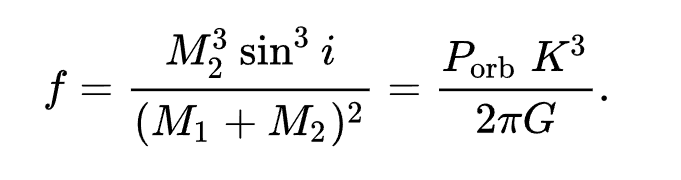

f = $\frac{{M_2}^{3}\sin^3(i)}{(M_1 + M_2)^2}$, $M_1 = M_{tot} - M_2$  
f = $\frac{{M_2}^{3}\sin^3(i)}{(M_{tot})^2}$,                        
$M_{tot}f = {M_2}^{3}\sin^3(i)$                                     
$M_2 = \frac{(M_{tot}f)^{\frac{1}{3}}}{\sin(i)}$

In [ ]:
K = 45.66 * 1e3 #m/s see: https://vizier.cds.unistra.fr/viz-bin/VizieR-5?-out.add=.&-source=B/sb9&Seq=2412

f_binary = 0.1099 * M_sun #K**3 / (G * ω) # 0.1019 * M_sun 0.0002

M2 = ( (f_binary * M_tot**2) / np.sin(inc * (np.pi/180))**3 )**(1/3)
M1 = M_tot - M2

In [ ]:
print('ω =', ω, 's^-1')
print('R1 =', R1/R_sun, r'R_sun')
print('R2 =', R2/R_sun, r'R_sun')
print('a =', semimajor_axis/AU, 'AU', 'or', semimajor_axis/R_sun, r'R_sun')
print('M_tot =',M_tot/M_sun, 'M_sun', 'or', M_tot, 'kg')
print('M2 =',M2/M_sun,'M_sun', 'or', M2, 'kg')
print('M1 =',M1/M_sun, 'M_sun', 'or', M1, 'kg')

In [ ]:
def orbital_parameters(vsini, P_rot, inc, R_ratio, a_R_ratio, f_binary):
    #rotational period
    ω_rot = 2*np.pi/(P_rot * 24 *3600) #for consistency sake 
    r1 = vsini/(np.sin(inc*(np.pi/180))*ω_rot)
    r2 = r1*R_ratio
    
    #orbital parameters
    a_tot = a_R_ratio * (r1+r2)
    M_tot = (ω_rot**2 * (a_tot * 1e3)**3 / G)
    
    f_binary = f_binary * M_sun
    
    M2 = ( (f_binary * M_tot**2) / np.sin(inc * (np.pi/180))**3 )**(1/3)
    M1 = M_tot - M2
    return ω_rot, r1, r2, a_tot, M_tot, M2, M1

In [ ]:
def orbit_errors(params, errors):
    calc_params = np.array(orbital_parameters(params[0], params[1], params[2], 
                       params[3], params[4], params[5]))
    
    plus_params = np.array(params) + np.array(errors)
    minus_params = np.array(params) - np.array(errors)
    
    if plus_params[2] > 90:
        plus_params[2] = 90
    
    calc_plus = np.array(orbital_parameters(plus_params[0], plus_params[1], 
                                            plus_params[2], plus_params[3], 
                                            plus_params[4], plus_params[5]))
    
    calc_minus = np.array(orbital_parameters(minus_params[0], minus_params[1], 
                                             minus_params[2], minus_params[3], 
                                             minus_params[4], minus_params[5]))
    plus_error = calc_plus -  calc_params
    minus_error = calc_minus - calc_params
    return plus_error, minus_error

In [ ]:
vsini_error = 0.6163918306474289
plus_error, minus_error = orbit_errors([av_vsini, rot_period, inc, radius_ratio, a_to_R_ratio, 0.1099], 
             [vsini_error,0.1,5,0.01,0.1, 0.0002])

In [ ]:
print(plus_error)
print(minus_error)

In [ ]:
#MASSES (with errors)
print('Lower Bounds for errors - accounts for errors in vsini, binary mass function')
print('---------------------------------------------------------------------------------')
print('M_tot =',M_tot/M_sun, ' | +', plus_error[4]/M_sun, '/', minus_error[4]/M_sun, 'M_sun')
print('or', M_tot, ' | +', plus_error[4], '/', minus_error[4], 'kg')
print()
print('M2 =',M2/M_sun,' | +', plus_error[5]/M_sun, '/', minus_error[5]/M_sun,'M_sun')
print('or', M2,  ' | +', plus_error[5], '/', minus_error[5], 'kg')
print()
print('M1 =',M1/M_sun, ' | +', plus_error[6]/M_sun, '/', minus_error[6]/M_sun,'M_sun')
print('or', M1,  ' | +', plus_error[6], '/', minus_error[6], 'kg')

In [ ]:
print((M1 + plus_error[6])/M_sun)

In [ ]:
print((R2 + plus_error[2])/R_sun)
print((R2 + minus_error[2])/R_sun)
print((plus_error[2] - minus_error[2])/R_sun)

In [ ]:
print((plus_error[1])/R_sun)
print((-minus_error[2])/R_sun)

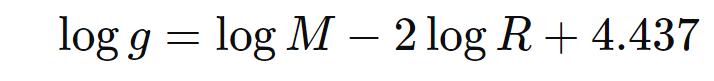

In [ ]:
print(M1/M_sun)
print(R1/R_sun)

logg = np.log10(M1/M_sun) - 2*np.log10(R1/R_sun) + 4.437

print(logg)

In [ ]:
R_peaks = abs(np.array(peak_diffs[:,2], dtype=np.float64))*(1/(np.sin(inc*(np.pi/180))*ω))
R_ps = abs(abs(np.array(peak_diffs[:,2], dtype=np.float64))*(1/(np.sin(inc*(np.pi/180))*ω)) - R1)#peak to surface
#Math: (v_peak - vsini)/sin(i)


BJDs_bluepeak = np.array([BJDs[2],BJDs[4],BJDs[5],BJDs[6]])
print('date', '\t\t','circumstellar distance')
for i in range(len(R_peaks)):
    print(peak_diffs[i,0],'\t', R_ps[i], 'km or', R_ps[i]/R_sun, 'R_sun')

In [ ]:
peak_data = {'Dates': peak_diffs[:,0], 'BJDs': BJDs_bluepeak, 'Raw Velocities (km/s)': peak_diffs[:,1], 
             'v_primary - v_peak (km/s)': peak_diffs[:,2], 'Dist from center (km)': R_peaks, 
             'Dist from center (R_sun)': R_peaks/R_sun, 'Dist from surface (km)': R_ps,
            'Dist from surface (R_sun)': R_ps/R_sun}
#df = pd.DataFrame(peak_data)
#print(df)

#df.to_csv('HUVir_flare_parameters.csv', index=False)

In [ ]:
T1 = 4400
T_sun = 5772 #5770

σ = 5.670374419e-8
L_sun = 3.828e26
#L 4pi (R^4) (T^4)
L_HUVir = (4*np.pi * σ *((R1*1e3)**2)*(T1**4))/L_sun



print(L_HUVir)

In [ ]:
T2 = T1 * 1.08

In [ ]:
print(T2)